100%|██████████| 9.91M/9.91M [00:00<00:00, 56.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 3.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.01MB/s]



Starting training...
Epoch [1/10], Step [100/938], Loss: 0.5135
Epoch [1/10], Step [200/938], Loss: 0.1821
Epoch [1/10], Step [300/938], Loss: 0.4426
Epoch [1/10], Step [400/938], Loss: 0.1980
Epoch [1/10], Step [500/938], Loss: 0.2696
Epoch [1/10], Step [600/938], Loss: 0.0515
Epoch [1/10], Step [700/938], Loss: 0.3856
Epoch [1/10], Step [800/938], Loss: 0.1146
Epoch [1/10], Step [900/938], Loss: 0.1198
Epoch [1/10] completed. Average Loss: 0.2664, Accuracy: 92.23%
Epoch [2/10], Step [100/938], Loss: 0.0339
Epoch [2/10], Step [200/938], Loss: 0.1175
Epoch [2/10], Step [300/938], Loss: 0.3761
Epoch [2/10], Step [400/938], Loss: 0.1241
Epoch [2/10], Step [500/938], Loss: 0.1275
Epoch [2/10], Step [600/938], Loss: 0.1647
Epoch [2/10], Step [700/938], Loss: 0.1486
Epoch [2/10], Step [800/938], Loss: 0.0948
Epoch [2/10], Step [900/938], Loss: 0.0789
Epoch [2/10] completed. Average Loss: 0.1124, Accuracy: 96.49%
Epoch [3/10], Step [100/938], Loss: 0.1192
Epoch [3/10], Step [200/938], Loss:

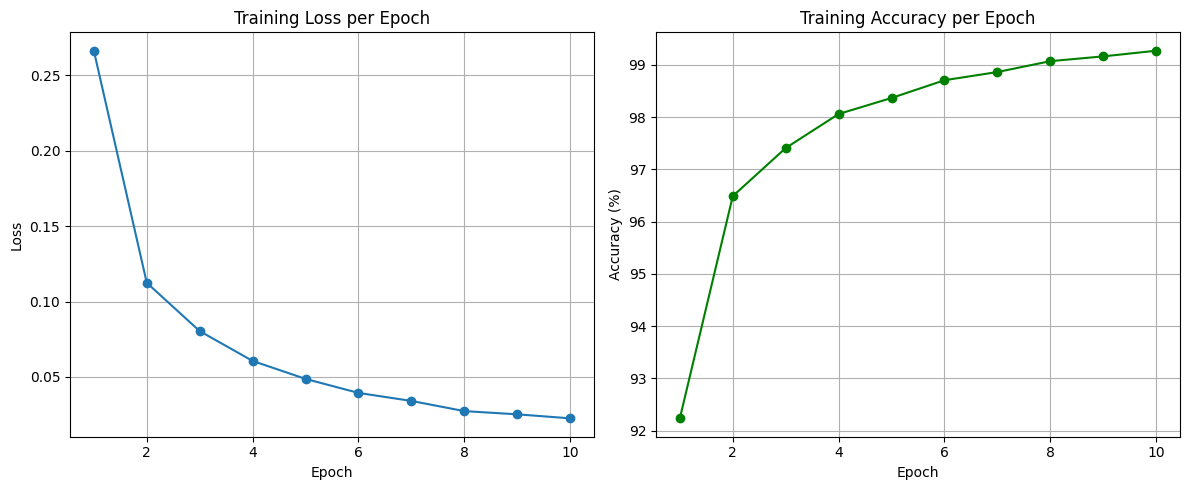

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = 28 * 28
num_classes = 10
learning_rate = 0.001
batch_size = 64
num_epochs = 10

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(-1, input_size)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

model = NeuralNet(input_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("\nStarting training...")
total_steps = len(train_loader)
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_steps}], Loss: {loss.item():.4f}')

    avg_epoch_loss = epoch_loss / len(train_loader.dataset)
    epoch_accuracy = (correct_predictions / total_samples) * 100
    train_losses.append(avg_epoch_loss)
    train_accuracies.append(epoch_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] completed. Average Loss: {avg_epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print("Training complete!")

print("\nStarting testing...")
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    test_accuracy = (correct / total) * 100
    print(f'Accuracy of the model on the {len(test_dataset)} test images: {test_accuracy:.2f}%')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', color='green')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()